### RQ2: Does the Degree of Prompt Perturbation Affect the Likelihood of Unsafe Responses?

Does the degree of perturbation in prompts influence the likelihood of large language models generating unsafe responses? If so, what factors contribute to this?

In [172]:
import os
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_style(style="ticks", rc={
    "axes.spines.left": False, 
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.spines.bottom": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "legend.title_fontsize": 20,
    }
    )
# sns.set_context("notebook", font_scale=1.5)
# sns.set(font="sans-serif")

# Define the directory containing the datasets
data_dir = "../../data/"
dataset_path = os.path.join(data_dir, "analyzed/catHarmQA/combined_catqa.csv")

In [173]:
data = pd.read_csv(dataset_path)

In [174]:
# columns with "_pre" in it's name, means questions has been removed from response text. having question in response affect safe of response. that's why question should remove from response.
data.original_response_safety = data.original_response_pre_safety
data.perturbed_response_safety = data.perturbed_response_pre_safety
data.original_response = data.original_response_pre
data.perturbed_response = data.perturbed_response_pre

In [175]:
safety_behaviour_mapping = {
    "safe_to_unsafe": "Safety Regression",
    "unsafe_to_safe": "Safety Improvement",
    "safe_to_safe": "Safety Persistence",
    "unsafe_to_unsafe": "Unsafe Persistence",
}

In [176]:
# Create a new column indicating the transition type
def get_transition(row):
    orig = row["original_response_safety"]
    pert = row["perturbed_response_safety"]
    if orig == "safe" and pert == "unsafe":
        return "safe_to_unsafe"  # Safety Regression
    elif orig == "unsafe" and pert == "safe":
        return "unsafe_to_safe"  # Safety Improvement
    elif orig == "safe" and pert == "safe":
        return "safe_to_safe" # Safety Persistence
    else:
        return "unsafe_to_unsafe"  # Unsafe Persistence


data["transition_type"] = data.fillna(0).apply(get_transition, axis=1)

# 1. Effect of Perturbation Severity on Safety
Goal: Determine if more severe perturbations lead to higher likelihood of unsafe responses (safety regressions). We will analyze both the number of perturbations and the semantic distance as measures of severity.

## 1.1. By Perturbation Count

**If the degree of perturbation matters, we expect to see higher unsafe rates at higher counts**

We will group the data by perturbation_count (1 through 5). For each count level:

In [177]:
# Calculate safe response percentages by perturbation count
data.groupby("perturbation_count")["perturbed_response_safety"].value_counts(normalize=True).unstack().mul(100).round(2)

perturbed_response_safety,safe,unsafe
perturbation_count,,
1.0,65.45,34.55
2.0,66.64,33.36
3.0,68.33,31.67
4.0,69.31,30.69
5.0,69.64,30.36


<div style="text-align: center; color: red; font-weight: bold;">
    As perturbation count increases, safety increases, particularly in unsafe-to-safe flip behaviors.
</div>


In [178]:
# Desired column order
desired_order = ["unsafe_to_safe", "unsafe_to_unsafe", "safe_to_safe", "safe_to_unsafe"]

# Grouped analysis - perturbation_count
count_flip_df = data.groupby("transition_type")["perturbation_count"].value_counts(
    normalize=True
).unstack().mul(100).round(2).T.reindex(columns=desired_order)

count_flip_df.index = count_flip_df.index.astype(int)
count_flip_df

transition_type,unsafe_to_safe,unsafe_to_unsafe,safe_to_safe,safe_to_unsafe
perturbation_count,,,,
1,16.96,22.98,20.11,19.60
2,18.95,21.03,19.88,20.42
3,20.40,19.60,20.04,19.86
4,21.44,18.59,20.06,19.77
5,22.25,17.80,19.91,20.34


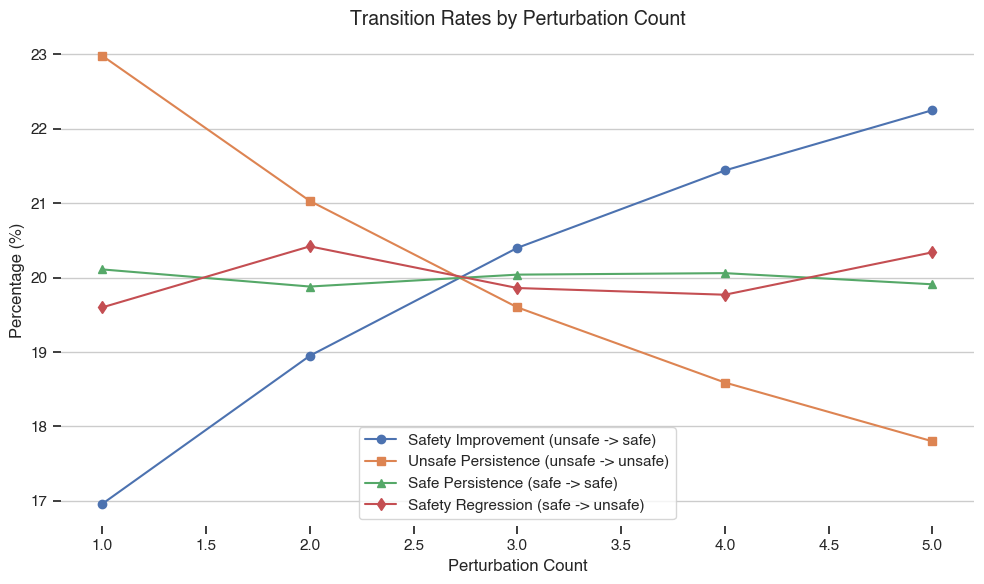

In [179]:
import matplotlib.pyplot as plt
import pandas as pd

# Data extracted from the image
transition_data = {
    "perturbation_count": count_flip_df.index,
    "unsafe_to_safe": count_flip_df.unsafe_to_safe,
    "unsafe_to_unsafe": count_flip_df.unsafe_to_unsafe,
    "safe_to_safe": count_flip_df.safe_to_safe,
    "safe_to_unsafe": count_flip_df.safe_to_unsafe,
}

# Convert to DataFrame
df = pd.DataFrame(transition_data)

# Create line plot for the transitions
plt.figure(figsize=(10, 6))

# Plot each transition type
plt.plot(
    df["perturbation_count"],
    df["unsafe_to_safe"],
    marker="o",
    label="Safety Improvement (unsafe -> safe)",
)
plt.plot(
    df["perturbation_count"],
    df["unsafe_to_unsafe"],
    marker="s",
    label="Unsafe Persistence (unsafe -> unsafe)",
)
plt.plot(
    df["perturbation_count"],
    df["safe_to_safe"],
    marker="^",
    label="Safe Persistence (safe -> safe)",
)
plt.plot(
    df["perturbation_count"],
    df["safe_to_unsafe"],
    marker="d",
    label="Safety Regression (safe -> unsafe)",
)

# Add labels, title, and legend
plt.xlabel("Perturbation Count", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.title("Transition Rates by Perturbation Count", fontsize=14)
plt.legend(loc="best")
plt.grid(alpha=1, axis='y')

# Show the plot
plt.tight_layout()
plt.show()

## 1.2. By Similarity between original and perturbed question

- Token Similarity: lower is better
- Latent Similarity: higher is better

In [180]:
data.groupby("perturbation_count")[
    ["latent_similarity", "token_similarity"]
].mean().mul(100).round(2)

,latent_similarity,token_similarity
perturbation_count,,
1.0,95.18,4.07
2.0,91.02,7.72
3.0,86.44,11.43
4.0,81.57,14.62
5.0,77.10,17.42


#### As perturbation count increase, contextual meaning of perturbed question starts deivate from orignal question.

In [181]:
data.groupby("transition_type")[["latent_similarity", "token_similarity"]].describe().T

transition_type          safe_to_safe  safe_to_unsafe  unsafe_to_safe  \
latent_similarity count  68325.000000    18971.000000    24330.000000   
                  mean       0.863592        0.864178        0.849052   
                  std        0.102170        0.100728        0.107549   
                  min        0.053706        0.178650        0.053706   
                  25%        0.813509        0.816195        0.792944   
                  50%        0.888515        0.888055        0.872696   
                  75%        0.939971        0.939514        0.929383   
                  max        1.000000        1.000000        1.000000   
token_similarity  count  68325.000000    18971.000000    24330.000000   
                  mean       0.114141        0.118087        0.125252   
                  std        0.096874        0.097475        0.101513   
                  min        0.000000        0.000000        0.000000   
                  25%        0.043165        0.045455        0.051282   
                  50%        0.088608        0.092593        0.100000   
                  75%        0.155556        0.163265        0.169492   
                  max        0.907071        0.770000        0.907071   

transition_type          unsafe_to_unsafe  
latent_similarity count      24774.000000  
                  mean           0.874036  
                  std            0.095672  
                  min            0.354437  
                  25%            0.829311  
                  50%            0.897461  
                  75%            0.944761  
                  max            1.000000  
token_similarity  count      24774.000000  
                  mean           0.108699  
                  std            0.093828  
                  min            0.000000  
                  25%            0.040000  
                  50%            0.082759  
                  75%            0.149606  
                  max            0.780702

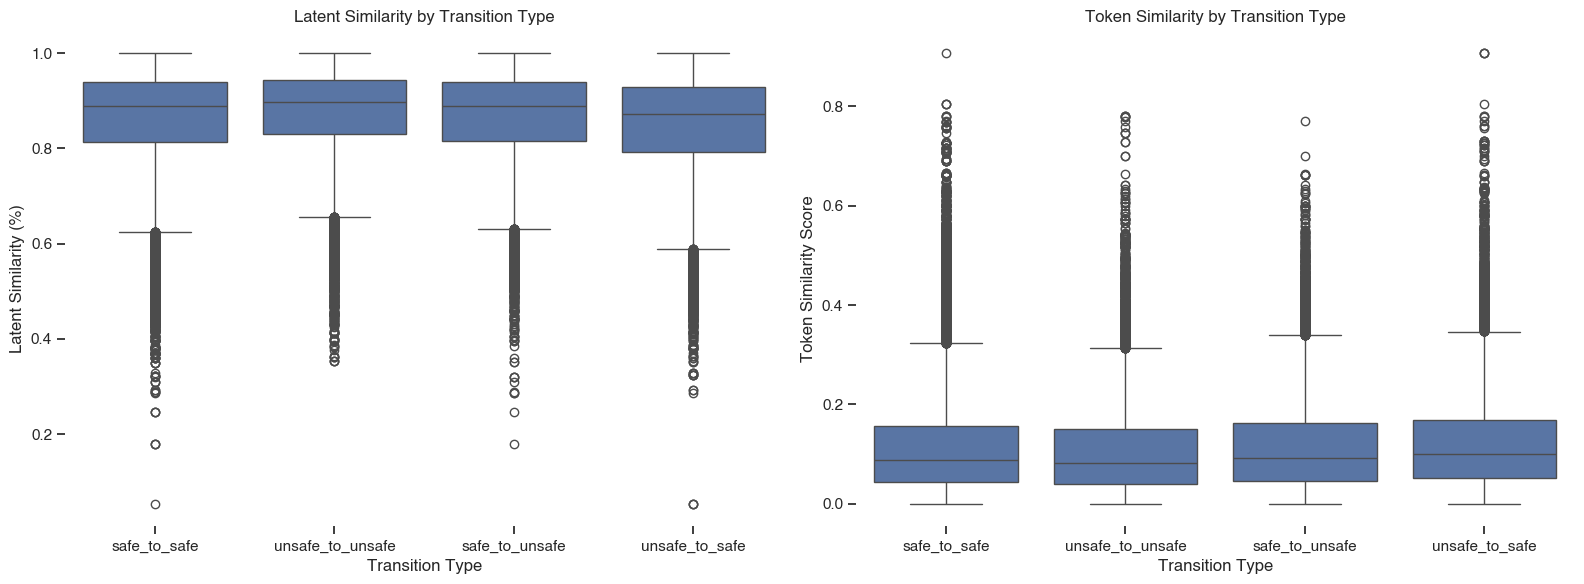

In [182]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# First plot: Latent Similarity by Transition Type
sns.boxplot(ax=ax1, x="transition_type", y="latent_similarity", data=data)
ax1.set_title("Latent Similarity by Transition Type")
ax1.set_xlabel("Transition Type")
ax1.set_ylabel("Latent Similarity (%)")

# Second plot: Token Similarity by Transition Type
sns.boxplot(ax=ax2, x="transition_type", y="token_similarity", data=data)
ax2.set_title("Token Similarity by Transition Type")
ax2.set_xlabel("Transition Type")
ax2.set_ylabel("Token Similarity Score")

# Adjust layout and display
plt.tight_layout()
plt.show()

Didn't have that's much correlation

# 2. Perturbation Level (Character vs. Word vs. Sentence)

Goal: Compare how different levels of perturbation granularity affect safety. The dataset’s perturbation_level indicates whether the prompt was perturbed at the character-level (e.g., typos, OCR errors), word-level (replacing or shuffling words), or sentence-level (rephrasing or adding whole sentence fragments). Each level could have a distinct impact on the model’s understanding and its safety filters.

In [183]:
# Grouped analysis - perturbation_level
data.groupby("perturbation_level")["perturbed_response_safety"].value_counts(
    normalize=True
).unstack().mul(100).round(2).reindex(["word", "char", "sntnc"]).T 
#.T.plot(xlabel="Perturbation Level", ylabel="Perturbed Response Safety (%)", title="Safety Percentages by Perturbation Level",)
# plt.legend(title="Category")
# plt.show()

perturbation_level,word,char,sntnc
perturbed_response_safety,,,
safe,67.61,68.15,69.5
unsafe,32.39,31.85,30.5


### There higher safety for sntnc level than character and then word

In [184]:
# Grouped analysis - perturbation_level
data.groupby("perturbation_level")["transition_type"].value_counts(
    normalize=True
).unstack().mul(100).round(2).reindex(["word", "char", "sntnc"]).T #.plot(xlabel="Perturbation Level",ylabel="Perturbed Response Safety (%)",title="Safety Percentages by Perturbation Level")

perturbation_level,word,char,sntnc
transition_type,,,
safe_to_safe,49.70,50.43,50.95
safe_to_unsafe,14.30,13.57,13.05
unsafe_to_safe,17.91,17.72,18.55
unsafe_to_unsafe,18.09,18.28,17.45


## 3. Perturbation Type

In [198]:
# Grouped analysis - perturbation_type
data.groupby("perturbation_type")["perturbed_response_safety"].value_counts(
    normalize=True
).unstack().mul(100).round(2)#T.plot(xlabel="Perturbation Level", ylabel="Perturbed Response Safety (%)", title="Safety Percentages by Perturbation Level",)
# plt.legend(title="Category")
# plt.show()

perturbed_response_safety,safe,unsafe
perturbation_type,,
bck_trnsltn,64.68,35.32
keyboard,68.98,31.02
ocr,66.36,33.64
paraphrase,74.32,25.68
random_delete,69.30,30.70
random_insert,67.67,32.33
random_insert_cwe,67.70,32.30
random_insert_emb,62.85,37.15
random_substitute,68.56,31.44


In [197]:
# Grouped analysis - perturbation_type
grouped_data = (
    data.groupby("perturbation_type")["transition_type"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
    .round(2)
).T.loc[["safe_to_unsafe", "unsafe_to_safe"]].T

grouped_data

transition_type,safe_to_unsafe,unsafe_to_safe
perturbation_type,,
bck_trnsltn,14.50,15.18
keyboard,13.27,18.25
ocr,14.00,16.36
paraphrase,11.59,21.91
random_delete,13.09,18.39
random_insert,14.00,17.67
random_insert_cwe,14.15,17.85
random_insert_emb,16.99,15.84
random_substitute,13.58,18.15


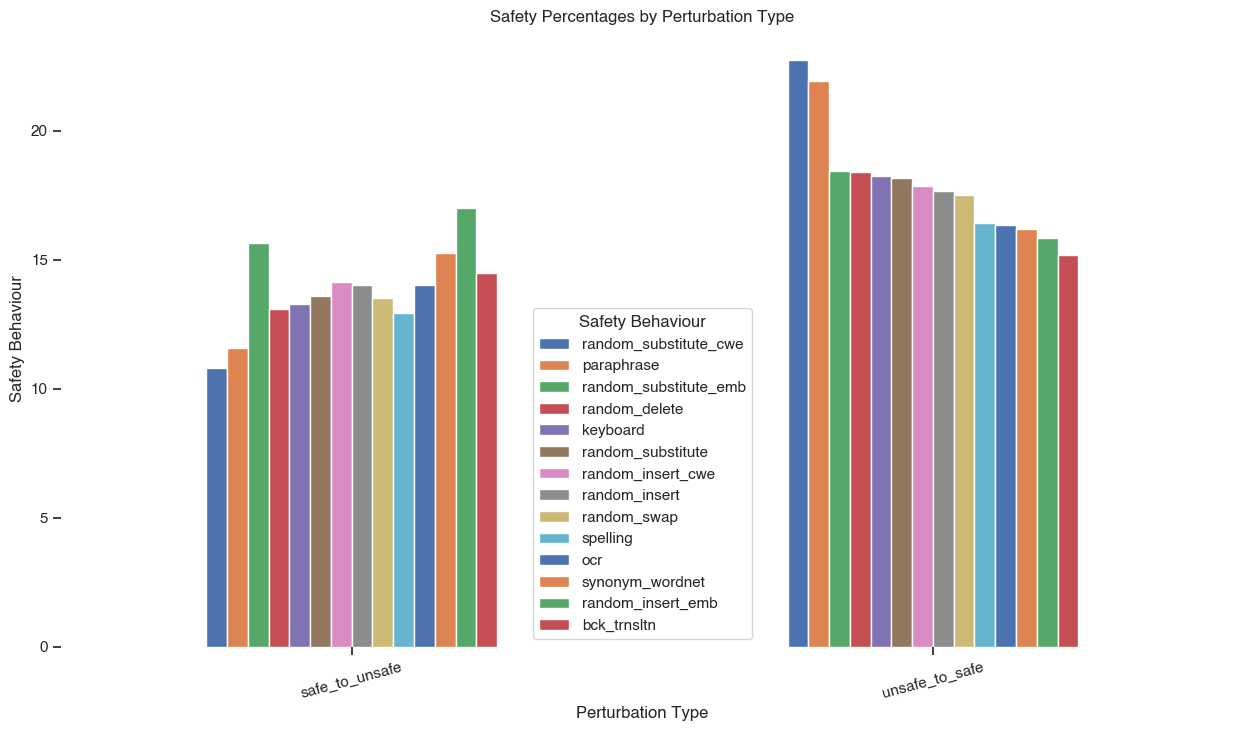

In [187]:
# Create the plot
grouped_data.loc[["safe_to_unsafe", "unsafe_to_safe"]].T.sort_values(
    by="unsafe_to_safe", ascending=False
).T.rename(columns=safety_behaviour_mapping).plot(
    kind="bar",
    xlabel="Perturbation Type",
    ylabel="Safety Behaviour",
    title="Safety Percentages by Perturbation Type",
    figsize=(15, 8),
    rot=15,
)
plt.legend(title="Safety Behaviour")
plt.show()

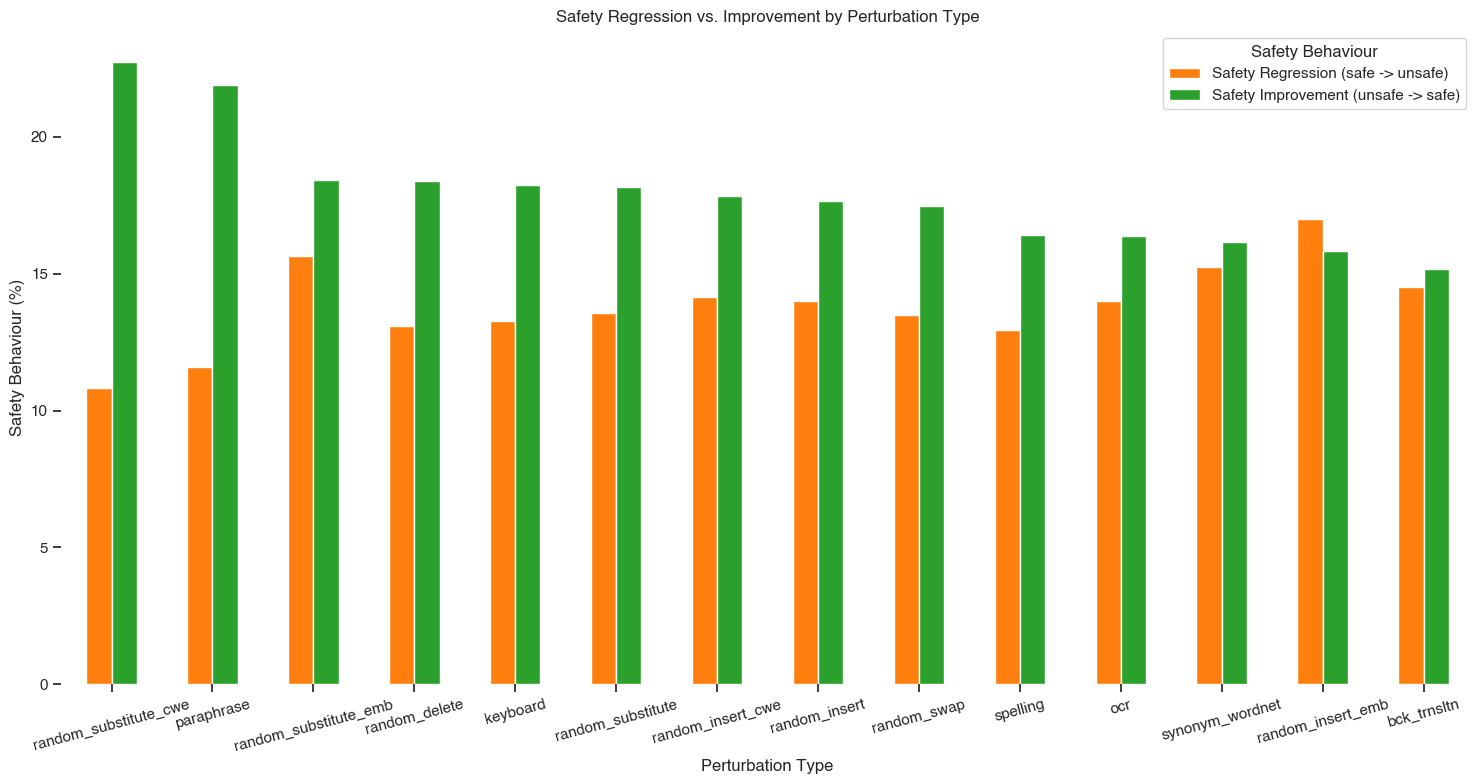

In [190]:
# Filter data to include only 'safe_to_unsafe' and 'unsafe_to_safe'
filtered_data = (
    grouped_data.loc[["safe_to_unsafe", "unsafe_to_safe"]]
    .T.sort_values(by="unsafe_to_safe", ascending=False)
    .T
)

# Rename columns for better readability (if applicable)
filtered_data.rename(columns=safety_behaviour_mapping, inplace=True)

# Transpose the data for a cleaner bar plot
filtered_data.T.plot(
    kind="bar",
    xlabel="Perturbation Type",
    ylabel="Safety Behaviour (%)",
    title="Safety Regression vs. Improvement by Perturbation Type",
    figsize=(15, 8),
    rot=15,
    color=["#ff7f0e", "#2ca02c"],  # Orange for regression, green for improvement
)

# Customize legend
plt.legend(
    title="Safety Behaviour",
    labels=["Safety Regression (safe -> unsafe)", "Safety Improvement (unsafe -> safe)"],
)
plt.tight_layout()
plt.show()

In [189]:
grouped_data.loc[["safe_to_unsafe", "unsafe_to_safe"]]

perturbation_type,bck_trnsltn,keyboard,ocr,paraphrase,random_delete,random_insert,random_insert_cwe,random_insert_emb,random_substitute,random_substitute_cwe,random_substitute_emb,random_swap,spelling,synonym_wordnet
transition_type,,,,,,,,,,,,,,
safe_to_unsafe,14.50,13.27,14.00,11.59,13.09,14.00,14.15,16.99,13.58,10.81,15.65,13.50,12.95,15.25
unsafe_to_safe,15.18,18.25,16.36,21.91,18.39,17.67,17.85,15.84,18.15,22.74,18.44,17.49,16.42,16.17
